# Classifier analysis

Use a classifier approach to assess prediction following statistical learning. Trains subject-specific classifiers to distinguish B scene categories in the pre-learning run from hippocampal subfield activity patterns, which are used to assess prediction of upcoming B categories during A scene viewing in the post-learning run.

## 0. Initialization

In [1]:
import warnings
import sys 
if not sys.warnoptions:
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=UserWarning)
import os 
import random
import nibabel as nib
import numpy as np
import pandas as pd
import scipy.io
import scipy.stats as st 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns 
import statsmodels.formula.api as sm
import time

from scipy import stats
from itertools import combinations
from nilearn.maskers import NiftiMasker

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, PredefinedSplit, StratifiedKFold, LeaveOneOut
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, f_classif, mutual_info_classif, SelectKBest, SelectPercentile
from sklearn.pipeline import Pipeline
from sklearn.model_selection import PredefinedSplit
from sklearn.preprocessing import StandardScaler

from brainiak.utils.fmrisim import _double_gamma_hrf as hrf_func
from brainiak.utils import fmrisim as sim

from utils import *


/gpfs/milgram/project/turk-browne/iz42/conda_envs/fmri_env/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


In [2]:
subinfo = pd.read_csv('./data/subject_info.txt', sep="\t")

excl_thresh = int(np.round((21*3)*0.6)) # exclude inattentive responders
usable_subinfo = subinfo[subinfo.fmri_scenes_usable == 1].reset_index(drop=True)
usable_subinfo = usable_subinfo[usable_subinfo.encoded_pairs >= excl_thresh].reset_index(drop=True)

subIDs = list(usable_subinfo.subid)
ctrl_subIDs = list(usable_subinfo[usable_subinfo.group == 0]["subid"])#.index)
stress_subIDs = list(usable_subinfo[usable_subinfo.group == 1]["subid"])#.index)
grp2name = {0: "Control", 1: "Stress"}
subid2grp = {usable_subinfo["subid"][i]: grp2name[usable_subinfo["group"][i]] for i in range(len(usable_subinfo))}

print("Controls:", len(ctrl_subIDs))
print("Stress:", len(stress_subIDs))

runs = ["scene1", "scene2", "scene3", "scene4", "scene5"]
rois = ["CA1", "CA23", "DG"]
abxs = ["A", "B", "X"]
groups = ["Control", "Stress"]

exclude_noresp = False
nan_noresp = True


Controls: 43
Stress: 45


## 1. Data Loading

In [3]:
masked_outdir = "./data/masked_fmri"

def load_masked_data(subid, run, roi):
    """
    Loads in masked fMRI data for a given subject, run, and ROI
    Args:
        subid (int): subject ID
        run (string): scene run label
        roi (string): ROI name
    Returns:
        (np.array): masked voxel data with shape (TRs, voxels)
    """
    
    datafile = f'{masked_outdir}/{roi}/masked_{roi}_sub{subid}_{run}.npy'
    data = np.load(datafile)

    return data


def normalize_bold(bold_data_run):
    """
    Normalize BOLD data; within each run, each voxel should have mean 0 and std 1 across TRs
    Args:
        bold_data_run (np.array): should have dimensions (TRs, voxels)
    """
    # exclude voxels with std 0
    bold_std = np.std(bold_data_run, axis=0)
    bold_normalized = (bold_data_run - np.mean(bold_data_run, axis = 0))/bold_std
    return bold_normalized


def trim_TRs(hipp_data, stimTRs):
    """
    Normalizes BOLD data, then trims to include only TRs during stimulus presentation (shifted by 3TR to account for hemodynamic lag)
    Args:
        hipp_data (np.array): fMRI data (masked)
        stimTRs (list OR np.array): list of TRs during stimulus presentation
    """
    
    # normalize BOLD data 
    hipp_data_norm = normalize_bold(hipp_data)
    
    trimmed_data = []
    for t in stimTRs:
        trimmed_data.append(hipp_data_norm[t+3])
    
    trimmed_data = np.array(trimmed_data)
    
    return trimmed_data


def load_subrun_data(subid, run, roi, ABX=['A','B','X'], label_shift=0, shuffle=False, seed=None):
    """
    Loads in all data for a given subject, run, and roi
    Args:
        subid (int): subject ID
        run (string): scene run label
        roi (string): ROI name
        ABX (string): Subset of ['A','B','X']; load only trials with these labels
        label_shift (int): shift labels backwards (negative) so labels are mapped to a preceding item or forwards (positive) so they are mapped to a subsequent item
    """
    r = int(run[-1])
    
    ABX_labels = get_ABX_labels(subid, r, exclude_noresp = True, nan_noresp = False)
    category_labels = get_category_labels(subid, r, exclude_noresp = True, nan_noresp = False)
    stim_TRs = get_stimulus_TRs(subid, r, exclude_noresp = True)
    
    # if shuffle, shuffle stimTRs (this effectively shuffles all associated labels, before any item selection takes place)
    if shuffle:
        rng = np.random.default_rng(seed=seed)
        rng.shuffle(stim_TRs)
    
    if label_shift < 0:
        ABX_labels = ABX_labels[-1*label_shift:]
        category_labels = category_labels[-1*label_shift:]
        stim_TRs = stim_TRs[:label_shift]
    elif label_shift > 0:
        ABX_labels = ABX_labels[:-label_shift]
        category_labels = category_labels[:-label_shift]
        stim_TRs = stim_TRs[label_shift:]
    
    l2g = labels2gencats(subid)
    l2g[np.nan] = np.nan
    l2g['nan'] = np.nan
    gen_labels = [l2g[c] for c in category_labels]
    
    bold_data = load_masked_data(subid, run, roi)
    norm_data = normalize_bold(bold_data)
    
    # in at least one case, the run was cut short and some TRs are missing. trim_TRs will not work and the data is excluded
    try:
        trimmed_data = trim_TRs(norm_data, stim_TRs)
        trimmed_data = np.nan_to_num(trimmed_data, nan=0, posinf=0, neginf=0) # voxels outside the brain will have nan or inf values after normalization. Zero these out.
        
        out_idx = np.where(np.isin(ABX_labels, ABX))[0]

        ABX_labels = np.array(ABX_labels)[out_idx]
        gen_labels = np.array(gen_labels)[out_idx]
        category_labels = np.array(category_labels)[out_idx]
        trimmed_data = trimmed_data[out_idx, :]

    except:
        print(f'Sub {subid}, run {run} not enough TRs')
        ABX_labels = None
        gen_labels = None
        category_labels = None
        trimmed_data = None
        
    return ABX_labels, gen_labels, category_labels, trimmed_data
    
    
def get_sub_labelsdata(subid, runs, roi, ABX=['A','B','X'], label_shift=0, shuffle=False, seed=None):
    gen_labels_sub = []
    data_sub = []
    data_err = False
    
    for run in runs:
        ABX_labels, gen_labels, cat_labels, data = load_subrun_data(subid, run, roi, ABX=ABX, label_shift=label_shift, shuffle=shuffle, seed=seed)
        if data is None:
            data_err = True
            break
        else:
            gen_labels_sub.append(gen_labels)
            data_sub.append(data)
    
    if not data_err:
        gen_labels_sub = np.concatenate(gen_labels_sub, axis=0)
        data_sub = np.concatenate(data_sub, axis=0)
        
    else:
        gen_labels_sub = None
        data_sub = None
    
    return gen_labels_sub, data_sub


## 2. Optimizing classifier hyperparameters
Determine a set of parameters (C, PercentBest k) to use for each ROI.   
For each subject (both groups), use leave-one-out cross-validation on training data to decode category identity (out of As, Bs, or Xs), generating a subject-level score for each hyperparam combo.  
Then average scores over all subjects to determine the best hyperparameter combo. 
Best hyperparameters are precomputed and saved out in midpoints/classifier_hyperparams/. To recompute, set overwrite=False. 


In [4]:
def best_hyperparameters(subIDs, roi, abx, num_cats_per_classifier=2, xval_fold_algo="LeaveOneOut", num_folds=None, Cs=None, ks=None, verbose=False):
    '''
    Determines the best hyperparameters for decoding scene category in the training set.
    Args:
        subIDs (list(int)): list of subject numbers to consider
        roi (str): region of interest
        abx (list(str)): which categories to classify (e.g. ["A"])
        num_cats_per_classifier (int): number of categories to use in classification (default = 2; pairwise)
        xval_fold_algo (str): algorithm to use for producing cross-validation folds; one of ["LeaveOneOut", "StratifiedKFold"] (default = "LeaveOneOut")
        num_folds (int): number of folds for KFold cross-validation (ignored with LeaveOneOut)
        Cs (list[int]): all values of hyperparameter C to test (default = None; set to [1])
        ks (list[int]): all values of hyperparameter k to test (default = None; set to [100/(i+1) for i in range(10)])
        verbose (bool): if True, prints out extra info
    '''
    
    np.random.seed(0)
    
    kbest_func = f_classif #mutual_info_classif

    # hyperparameter space we want to search over
    if Cs is None:
        Cs = [1]
    if ks is None:
        ks = [100/(i+1) for i in range(8)]

    # initializing the dictionary that stores the results of each hyperparameter combination
    hyperparam_dic = {"subid": [], "catgroup": [], "C": [], "k": [], "val_score": []}


    for subid in subIDs:
        print(subid, end=', ')
        # get data and labels for this subject
        labels, data = get_sub_labelsdata(subid, ["scene1"], roi, ABX=abx)

        # which labels are available for this subject? Enumerate the label combinations. 
        unique_labels = np.unique(labels)
        labelpairs = combinations(unique_labels, num_cats_per_classifier)

        for pair in labelpairs:
            # extract the subset of data involving this set of labels
            idx = np.where(np.isin(labels, pair))[0]
            cur_data = data[idx,:]
            cur_labels = labels[idx]

            # loop through potential hyperparmeter combinations
            for C in Cs:
                for k in ks:
                    # initialize StratifiedKFold cross-validation; TODO: this could also be leave-one-out
                    if xval_fold_algo == "StratifiedKFold":
                        kf = StratifiedKFold(n_splits=num_folds, shuffle=True)
                    elif xval_fold_algo == "LeaveOneOut":
                        kf = LeaveOneOut() # y parameter is ignored but exists for compatibility

                    # loop through folds, constructed with the current set of data
                    for i, (train_idx, val_idx) in enumerate(kf.split(cur_data, cur_labels)):
                        # initialize SVC
                        model = SVC(C=C, kernel="linear")#, class_weight='balanced')

                        fold_X_train = cur_data[train_idx]
                        fold_y_train = cur_labels[train_idx]
                        fold_X_val = cur_data[val_idx]
                        fold_y_val = cur_labels[val_idx]

                        # dimensionality reduction on the train set
                        dim_reduction_model = SelectPercentile(kbest_func, percentile=k)

                        # fit the dimensionality reduction model
                        dim_reduction_model = dim_reduction_model.fit(fold_X_train, fold_y_train)

                        # apply the dimensionality reduction model to the train and validation data
                        fold_X_train_transformed = dim_reduction_model.transform(fold_X_train)
                        fold_X_val_transformed = dim_reduction_model.transform(fold_X_val)

                        # fit the classifier
                        clf = model.fit(fold_X_train_transformed, fold_y_train)

                        # calculate accuracy on the test group
                        score_val = clf.score(fold_X_val_transformed, fold_y_val)

                        # save the score for this fold and category group
                        hyperparam_dic["subid"].append(subid)
                        hyperparam_dic["catgroup"].append("_".join(pair))
                        hyperparam_dic["C"].append(C)
                        hyperparam_dic["k"].append(k)
                        hyperparam_dic["val_score"].append(score_val)

    # average xval scores across pairs within subjects, then across subjects, to get an overall average validation score for each hyperparam combination
    hyperparam_df = pd.DataFrame(hyperparam_dic)
    hyperparam_df_interim = hyperparam_df.drop(columns="catgroup").groupby(["subid", "C", "k"]).mean().reset_index()
    hyperparam_df_avg = hyperparam_df_interim.drop(columns="subid").groupby(["C", "k"]).mean().reset_index()

    # also extract best subject-level hyperparameters
    hyperparam_df_sub = hyperparam_df_interim.sort_values(by=["subid", "val_score"], ascending=False).groupby(["subid"]).head(1).sort_values(by="subid", ascending=True).reset_index(drop=True)

    # sort the df by val_score in descending order, print out the results, and extract the best set of parameters
    hyperparam_df_avg_sorted = hyperparam_df_avg.sort_values(by="val_score", axis="index", ascending=False).reset_index(drop=True)
    best_row = hyperparam_df_avg_sorted.iloc[0]
    best_C = best_row["C"]
    best_k = best_row["k"]
    best_valscore = best_row["val_score"]

    if verbose:
        print("Best overall hyperparameters")
        print(hyperparam_df_avg_sorted)
        print(f"Best C: {best_C}")
        print(f"Best k: {best_k}")
        print(f"Best valscore: {best_valscore}")

    return best_C, best_k, best_valscore



In [5]:
# determine the best set of hyperparameters for each ROI and condition (A/B/X).
overwrite = False # set to True to recompute
best_hyperparams_file = f'./midpoints/classifier_hyperparams/classifier_best_hyperparams_exclthresh{excl_thresh}.csv'

if not overwrite and os.path.isfile(best_hyperparams_file):
    cur_df = pd.read_csv(best_hyperparams_file)
    best_hyperparams = {'roi': list(cur_df['roi']), 
                        'abx': list(cur_df['abx']), 
                        'best_C': list(cur_df['best_C']), 
                        'best_k': list(cur_df['best_k']), 
                        'best_valscore': list(cur_df['best_valscore'])}
    
else:
    best_hyperparams = {'roi': [], 'abx': [], 'best_C': [], 'best_k': [], 'best_valscore': []}

for roi in rois:
    for abx in abxs:
        # if not overwriting, check if best_hyperparams already has this entry. If so, skip. Otherwise, add.
        entry_exists = False
        if not overwrite and os.path.isfile(best_hyperparams_file):
            entry_exists = ((cur_df['roi'] == roi) & (cur_df['abx'] == abx)).any()
            
        if overwrite or not entry_exists:
            print('\n', roi, abx)
            best_C, best_k, best_valscore = best_hyperparameters(subIDs, roi=roi, abx=abx, num_cats_per_classifier=2, xval_fold_algo="LeaveOneOut", num_folds=None, Cs=None, ks=None, verbose=False)

            best_hyperparams["roi"].append(roi)
            best_hyperparams["abx"].append(abx)
            best_hyperparams["best_C"].append(best_C)
            best_hyperparams["best_k"].append(best_k)
            best_hyperparams["best_valscore"].append(best_valscore)

best_hyperparams_df = pd.DataFrame(best_hyperparams)
best_hyperparams_df.to_csv(best_hyperparams_file, index=False)


## 3. Classifier Functions

In [6]:
def train_classify_gencat(traindata, trainlabel, dim_red, params):
    '''
    Train classifier (on a single subject's data) and output the trained dimensionaliy reduction and classifier models
    '''
    np.random.seed(0)
    
    unique_labels = np.unique(trainlabel)
    labelpairs = combinations(unique_labels, 2)
    
    classifiers = {}
    dimredmodels = {}
    
    for pair in labelpairs:
        trainidx = np.where(np.isin(trainlabel, pair))[0]
        X_train = traindata[trainidx, :]
        y_train = trainlabel[trainidx]
        
        if dim_red == "KBest":
            dim_reduction_model = SelectKBest(f_classif, k = params['k'])
        elif dim_red == "PercentBest":
            dim_reduction_model = SelectPercentile(f_classif, percentile = params['k'])
        
        # fit the dimensionality reduction model to the training data
        dim_reduction_model = dim_reduction_model.fit(X_train, y_train)

        # transform training data
        X_train_transformed = dim_reduction_model.transform(X_train)
        
        # train model on transformed training data
        model = SVC(C=params['C'], kernel="linear", max_iter=10000)#, class_weight="balanced")
        model.fit(X_train_transformed, y_train)
        
        # save out fitted training and dimensionality reduction model
        classifiers[pair] = model
        dimredmodels[pair] = dim_reduction_model
    
    return classifiers, dimredmodels
            
        

In [7]:
def test_classify_gencat(classifiers, dimredmodels, testdata, testlabel):
    '''
    Intended to follow train_classifier_gencat; tests clssifier on the same subject's data (useful if testing on many iterations of data without the need for retraining)
    '''
    np.random.seed(0)
    
    unique_labels = np.unique(testlabel)
    labelpairs = combinations(unique_labels, 2)
    
    scores = []
    
    for pair in labelpairs:
        testidx = np.where(np.isin(testlabel, pair))[0]
        X_test = testdata[testidx, :]
        y_test = testlabel[testidx]
        
        classifier = classifiers[pair]
        dim_reduction_model = dimredmodels[pair]
        
        # transform testing data
        X_test_transformed = dim_reduction_model.transform(X_test)
        
        # score model on transformed testing data
        clf = classifiers[pair]
        score = clf.score(X_test_transformed, y_test)
        
        scores.append(score)
    
    return np.mean(scores)
        

In [8]:
def run_classifier(subIDs, train_runs, test_runs, classifier_type, roi, dim_red, params=None):
    '''
    params (dict): dictionary mapping 'C' and 'k' to parameters; if None, pulls from best_hyperparams_df
    '''
    actual_subIDs = []
    scores = []
    
    if params is None:
        best_hyperparams_file = f'./midpoints/classifier_hyperparams/classifier_best_hyperparams_exclthresh{excl_thresh}.csv'
        best_hyperparams_df = pd.read_csv(best_hyperparams_file)
        hyperparams = best_hyperparams_df.loc[(best_hyperparams_df["roi"] == roi) & (best_hyperparams_df["abx"] == classifier_type[0])].reset_index(drop=True)
        params = {'C': hyperparams["best_C"][0], 'k': hyperparams["best_k"][0]} # CA23, C=1, k=20 (thresh 38)
    
    for subid in subIDs:
        if classifier_type == "B_prediction":
            train_labels, train_data = get_sub_labelsdata(subid, train_runs, roi, ABX=['B'], shuffle=False)
            test_labels, test_data = get_sub_labelsdata(subid, test_runs, roi, ABX=['A'], shuffle=False)

            if train_labels is None or test_labels is None:
                continue
            else:
                actual_subIDs.append(subid)
                test_labels = np.array([s.replace('A', 'B') for s in test_labels]) # B prediction
                
        elif classifier_type == 'A_lingering':
            train_labels, train_data = get_sub_labelsdata(subid, train_runs, roi, ABX=['A'], shuffle=False)
            test_labels, test_data = get_sub_labelsdata(subid, test_runs, roi, ABX=['B'], shuffle=False)

            if train_labels is None or test_labels is None:
                continue
            else:
                actual_subIDs.append(subid)
                test_labels = np.array([s.replace('B', 'A') for s in test_labels]) # A lingering
        
        elif "perception" in classifier_type:
            train_labels, train_data = get_sub_labelsdata(subid, train_runs, roi, ABX=[classifier_type[0]], shuffle=False)
            test_labels, test_data = get_sub_labelsdata(subid, test_runs, roi, ABX=[classifier_type[0]], shuffle=False)
            if train_labels is None or test_labels is None:
                continue
            else:
                actual_subIDs.append(subid)

        classifiers, dimredmodels = train_classify_gencat(train_data, train_labels, dim_red, params)
        scores.append(test_classify_gencat(classifiers, dimredmodels, test_data, test_labels))

        
    return scores, actual_subIDs


## 4. Run classifier for each group and ROI (Figure 2B)

We run the classifier for each participant in each ROI (CA1, CA2/3, DG). This is saved out in a CSV (precomputed for time). To rerun classifiers, set overwrite=True.   
The results are loaded in from the CSV and plotted. 


In [9]:
train_runs = ["scene1"]
test_runs = ["scene5"]
classifier_types = ["B_prediction"]
dim_red = "PercentBest"
overwrite = False

for roi in rois:
    print('\n', roi)
    unified_file = f'./midpoints/summary/classifier_besthyperparams_{roi}.csv'
    
    if overwrite or not os.path.isfile(unified_file):
        unified_df = pd.DataFrame({'subID': subIDs})

        for classifier_type in classifier_types:
            print(classifier_type, end=',')
            scores, actual_subIDs = run_classifier(subIDs, train_runs, test_runs, classifier_type, roi, dim_red, params=None)
            cur_df = pd.DataFrame({'subID': actual_subIDs, classifier_type: scores})

            nullmeans = []
            nullstds = []
            for sub in actual_subIDs:
                nulldist = np.load(f"./midpoints/classifier_nulldist/sub{sub}_{roi}_{classifier_type.replace('_', '')}_train1_test{''.join([r[-1] for r in test_runs])}_iterations{iterations}.npy")
                nullmeans.append(np.mean(nulldist))
                nullstds.append(np.std(nulldist))

            cur_df["null_mean"] = nullmeans
            cur_df["null_std"] = nullstds
            cur_df[f"{classifier_type}_z"] = (cur_df[classifier_type] - cur_df["null_mean"])/cur_df["null_std"]
            cur_df.loc[(cur_df[classifier_type] == cur_df["null_mean"]) & (cur_df["null_std"] == 0)] = cur_df.loc[(cur_df[classifier_type] == cur_df["null_mean"]) & (cur_df["null_std"] == 0)].fillna(0)

            unified_df = pd.merge(unified_df, cur_df.drop(columns=["null_mean", "null_std"]), on="subID", how="left")

        unified_df.to_csv(unified_file, index=False)


 CA1

 CA23

 DG


Control CA1: 95% CI [0.494, 0.5328]; p=0.0918; r=0.2889
Control CA23: 95% CI [0.4982, 0.5421]; p=0.0364; r=0.3714
Control DG: 95% CI [0.4738, 0.513]; p=0.2433; r=-0.1186
Stress CA1: 95% CI [0.4726, 0.5101]; p=0.1863; r=-0.1437
Stress CA23: 95% CI [0.5005, 0.548]; p=0.0228; r=0.3821
Stress DG: 95% CI [0.4871, 0.5242]; p=0.2749; r=0.1423


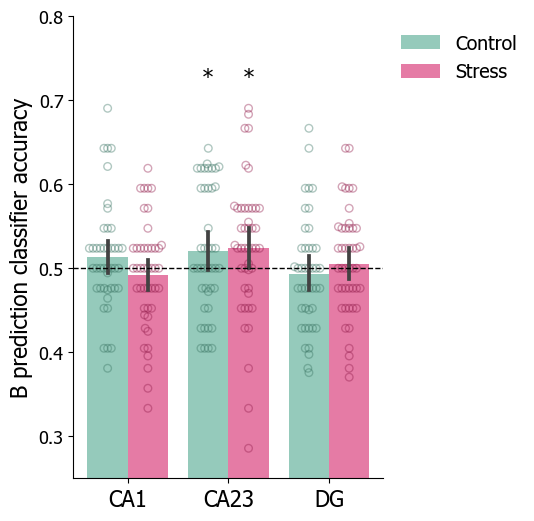

In [10]:
# load in and plot results of a single classifier type for all hippocampal subfields
plot_rois = rois
palette = group_colors
dark_palette = dark_group_colors
classifier_type = "B_prediction"
classifier_name = "B prediction"

sub2grp_df = usable_subinfo[["subid", "group"]].rename(columns={"subid": "subID"})
sub2grp_df["group"] = sub2grp_df["group"].apply(lambda x: grp2name[x])

plot_df = []
for i, roi in zip(np.arange(len(plot_rois)), plot_rois):
    unified_file = f'./midpoints/summary/classifier_besthyperparams_{roi}.csv'
    unified_df = pd.read_csv(unified_file)[["subID", classifier_type]]
    
    unified_df["roi"] = [roi]*len(unified_df)
    
    plot_df.append(unified_df)

plot_df = pd.concat(plot_df)
plot_df = pd.merge(plot_df, sub2grp_df, on="subID")

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
sns.barplot(ax=ax, data=plot_df, x="roi", y=classifier_type, hue="group", order=plot_rois, hue_order=groups, palette=palette, saturation=1)
sns.swarmplot(ax=ax, data=plot_df, x="roi", y=classifier_type, hue="group", order=plot_rois, hue_order=groups, palette=dark_palette, dodge=True, s=2.5, alpha=0, legend=False)

for roii in np.arange(len(plot_rois)):
    for groupi in np.arange(len(groups)):
        i = groupi + roii*len(groups)
        x_data, y_data = ax.collections[i].get_offsets().T
        ax.scatter(x_data, y_data, color="None", edgecolor=dark_palette[groupi], s=30, alpha=0.4)

    
ax.set_ylim(0.25, 0.8)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=14)
ax.set_xlabel("")
ax.set_ylabel(f"{classifier_name} classifier accuracy", fontsize=16)
ax.set_xticklabels(plot_rois, fontsize=16)
ax.set_yticks(np.arange(0.3, 0.81, 0.1))
ax.set_yticklabels([f'{i:.01f}' for i in np.arange(0.3, 0.81, 0.1)], fontsize=13)

ax.axhline(0.5, color='k', linewidth=1, linestyle='dashed')
sns.despine()

###############################
# Compute statistics
###############################
np.random.seed(0)

chance = 0.5
plot_df_pivot = plot_df.pivot(index=list(plot_df.columns[~np.isin(plot_df.columns, ["roi", "group", classifier_type])]) + ["group"], columns="roi", values=classifier_type).reset_index().dropna()

barxs = np.array([line.get_data()[0][0] for line in ax.get_lines()[:-1]]).reshape(len(groups), len(rois))
scatterys = [np.max(plot_df_pivot[s]) for s in rois]
yshift = np.diff(ax.get_ylim())*0.05

for group, groupi in zip(groups, np.arange(len(groups))):
    grp_df = plot_df_pivot[plot_df_pivot["group"] == group]
    for roi, roii in zip(rois, np.arange(len(rois))):
        roi_vals = np.array(grp_df[roi])
        
        CI, pval = simple_bootstrap(roi_vals, null=chance, iterations=99999, onetail_hyp="any")
        rbc = wilcoxon_effsize(roi_vals-chance, alternative="above", verbose=False)
        
        # convert p-value to stars and determine star position
        stars = pval2star(pval)
        starx = barxs[groupi, roii]
        stary = scatterys[roii] + yshift
        
        ax.text(x=starx, y=stary, s=stars, horizontalalignment="center", fontsize=16)
        
        print(f"{group} {roi}: 95% CI {[np.round(i, 4) for i in CI]}; p={np.round(pval, 4)}; r={np.round(rbc, 4)}")
        
plt.plot();


### Scanner Effects

In [11]:
bw_first_sub = 56
scaneff_roi = "CA23"

roi_df = plot_df[plot_df["roi"] == scaneff_roi]
bic_df = roi_df[roi_df["subID"] < bw_first_sub]
bw_df = roi_df[roi_df["subID"] >= bw_first_sub]

for group in groups:
    print(group)
    bic_val = np.array(bic_df[bic_df["group"] == group][classifier_type])
    bw_val = np.array(bw_df[bw_df["group"] == group][classifier_type])
    
    print(scipy.stats.ttest_ind(bic_val, bw_val))

Control
Ttest_indResult(statistic=1.4332127588971333, pvalue=0.15937904456493981)
Stress
Ttest_indResult(statistic=0.7925403270718879, pvalue=0.4323967158466905)


### Cortisol Effects

In [12]:
classifier_df = pd.read_csv("./midpoints/summary/classifier_besthyperparams_CA23.csv")[["subID", "B_prediction"]]
cort_df = pd.read_csv("./midpoints/summary/Day1_cortisol_react.csv")[["subID", "group", "cort_react"]]
merge_df = pd.merge(classifier_df, cort_df, on="subID", how="left")

r_lme(merge_df.dropna(), formula="B_prediction ~ cort_react * group", random_formula="~ 1 | subID")

,numDF,denDF,F-value,p-value
(Intercept),1,71.0,3545.094034,0.000000
cort_react,1,71.0,1.781130,0.186275
group,1,71.0,3.649345,0.060130
cort_react:group,1,71.0,0.223506,0.637832


## 5. Creating null distributions for B category prediction classifier
Null distributions have been pre-generated and saved in midpoints/classifier_nulldist. To generate from scratch, set overwrite=True. 

In [13]:
def run_classifier_nulldist(subIDs, train_runs, test_runs, classifier_type, roi, dim_red, params=None, iterations=9999, overwrite=False, filesuffix=''):
    '''
    params (dict): dictionary mapping 'C' and 'k' to parameters; if None, pulls from best_hyperparams_df
    '''
    actual_subIDs = []
    
    if params is None:
        best_hyperparams_file = f'./midpoints/classifier_hyperparams/classifier_best_hyperparams_exclthresh{excl_thresh}.csv'
        best_hyperparams_df = pd.read_csv(best_hyperparams_file)
        hyperparams = best_hyperparams_df.loc[(best_hyperparams_df["roi"] == roi) & (best_hyperparams_df["abx"] == classifier_type[0])].reset_index(drop=True)
        params = {'C': hyperparams["best_C"][0], 'k': hyperparams["best_k"][0]} # CA23, C=1, k=20 (thresh 38)
    
    for subid in subIDs:
        print('', subid, end='')
        # dataframe for saving out shuffled classifier performance 
        sub_scores = np.full(iterations, np.nan)
        sub_scores_outfile = f"./midpoints/classifier_nulldist/sub{subid}_{roi}_{classifier_type.replace('_', '')}_train{''.join([s[-1] for s in train_runs])}_test{''.join([s[-1] for s in test_runs])}_iterations{iterations}.npy"
        
        # only run this part if the shuffled classifier scores have not been precomputed
        if overwrite or not os.path.isfile(sub_scores_outfile):
            if classifier_type == "B_prediction":
                train_labels, train_data = get_sub_labelsdata(subid, train_runs, roi, ABX=['B'], shuffle=False)
                test_labels, test_data = get_sub_labelsdata(subid, test_runs, roi, ABX=['A'], shuffle=False) # still get the proper labels once to check that they exist

                if train_labels is None or test_labels is None:
                    continue
                else:
                    # add subID to the list of subjects with intact train/test data
                    actual_subIDs.append(subid)

                    # train the classifier
                    classifiers, dimredmodels = train_classify_gencat(train_data, train_labels, dim_red, params)

                    # loop through `iterations` number of shuffles, process labels, score the classifier on the resulting shuffled test data, and save out results
                    for i in range(iterations):
                        if iterations >= 10 and i%(iterations//10) == 0:
                            print('.', end='')
                        cur_test_labels, cur_test_data = get_sub_labelsdata(subid, test_runs, roi, ABX=['A'], shuffle=True, seed=i)
                        cur_test_labels = np.array([s.replace('A', 'B') for s in cur_test_labels]) # B prediction
                        sub_scores[i] = test_classify_gencat(classifiers, dimredmodels, cur_test_data, cur_test_labels)


            elif classifier_type == 'A_lingering':
                train_labels, train_data = get_sub_labelsdata(subid, train_runs, roi, ABX=['A'], shuffle=False)
                test_labels, test_data = get_sub_labelsdata(subid, test_runs, roi, ABX=['B'], shuffle=False) # still get the proper labels once to check that they exist

                if train_labels is None or test_labels is None:
                    continue
                else:
                    # add subID to the list of subjects with intact train/test data
                    actual_subIDs.append(subid)
                    
                    # train the classifier
                    classifiers, dimredmodels = train_classify_gencat(train_data, train_labels, dim_red, params)
                    
                    # loop through `iterations` number of shuffles, process labels, score the classifier on the resulting shuffled test data, and save out results
                    for i in range(iterations):
                        if iterations >= 10 and i%(iterations//10) == 0:
                            print('.', end='')
                        cur_test_labels, cur_test_data = get_sub_labelsdata(subid, test_runs, roi, ABX=['A'], shuffle=True, seed=i)
                        cur_test_labels = np.array([s.replace('B', 'A') for s in cur_test_labels]) # A lingering
                        sub_scores[i] = test_classify_gencat(classifiers, dimredmodels, cur_test_data, cur_test_labels)


            elif "perception" in classifier_type:
                train_labels, train_data = get_sub_labelsdata(subid, train_runs, roi, ABX=[classifier_type[0]], shuffle=False)
                test_labels, test_data = get_sub_labelsdata(subid, test_runs, roi, ABX=[classifier_type[0]], shuffle=False) # still get the proper labels once to check that they exist
                
                if train_labels is None or test_labels is None:
                    continue
                else:
                    # add subID to the list of subjects with intact train/test data
                    actual_subIDs.append(subid)
                    
                    # train the classifier
                    classifiers, dimredmodels = train_classify_gencat(train_data, train_labels, dim_red, params)
                    
                    # loop through `iterations` number of shuffles, score the classifier on the resulting shuffled test data, and save out results
                    for i in range(iterations):
                        if iterations >= 10 and i%(iterations//10) == 0:
                            print('.', end='')
                        cur_test_labels, cur_test_data = get_sub_labelsdata(subid, test_runs, roi, ABX=[classifier_type[0]], shuffle=True, seed=i)
                        sub_scores[i] = test_classify_gencat(classifiers, dimredmodels, cur_test_data, cur_test_labels)

            # save the scores as a npy file
            np.save(sub_scores_outfile, sub_scores)
        
    return actual_subIDs


In [14]:
params = None
classifier_type = "B_prediction"

for roi in rois:
    print('\n', roi, classifier_type)
    _ = run_classifier_nulldist(subIDs, ['scene1'], ['scene5'], classifier_type, roi, 'PercentBest', params=params, iterations=999, overwrite=False)



 CA1 B_prediction
 2 3 4 5 7 8 10 13 14 15 17 20 21 23 24 28 29 30 31 32 33 34 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 68 69 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 98 100 101 103 104 105 106
 CA23 B_prediction
 2 3 4 5 7 8 10 13 14 15 17 20 21 23 24 28 29 30 31 32 33 34 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 68 69 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 98 100 101 103 104 105 106
 DG B_prediction
 2 3 4 5 7 8 10 13 14 15 17 20 21 23 24 28 29 30 31 32 33 34 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 68 69 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 98 100 101 103 104 105 106

## 6. Run randomization test or CA2/3 B category prediction classifier (Supplemental Figure S1)

We train and test the classifier to predict upcoming B categories from CA2/3 activity, generating actual classifier performance for each subject.  
Actual classifier performance is then converted to z-scores based on subject-specific null distributions generated from the previous section.


In [15]:
def get_percentile_nulldist(score, nulldist):
    if score == np.median(nulldist):
        percentile = 50
    else:
        percentile = 100*(np.mean(score > nulldist) + np.mean(score == nulldist)/2)

    return percentile

In [16]:
# run the B category prediction classifier for CA2/3
np.random.seed(0)

subID_groups = [ctrl_subIDs, stress_subIDs]
params=None
train_runs = ['scene1']
test_runs = ['scene5']
classifier_type = 'B_prediction'
roi = 'CA23'
dim_red = 'PercentBest'

actual_subID_groups = []
score_groups = []

# run the classifier for each group
for use_subIDs, grpname in zip(subID_groups, groups):
    scores, actual_subIDs = run_classifier(use_subIDs, train_runs, test_runs, classifier_type, roi, dim_red, params=params)
    score_groups.append(scores)
    actual_subID_groups.append(actual_subIDs)

# create df to store classifier results
classifier_df = {'subID': [], 'group': [], 'score': []}
for i in range(len(groups)):
    classifier_df['subID'] += list(actual_subID_groups[i])
    classifier_df['group'] += [groups[i]]*len(actual_subID_groups[i])
    classifier_df['score'] += score_groups[i]

classifier_df = pd.DataFrame(classifier_df)


/gpfs/milgram/project/turk-browne/iz42/conda_envs/fmri_env/lib/python3.7/site-packages/ipykernel_launcher.py:40: FutureWarning: Passing `palette` without assigning `hue` is deprecated.


Control: 95% CI [-0.0181, 0.5586], p=0.0332, r=0.3129
Stress: 95% CI [-0.0052, 0.5975], p=0.0271, r=0.3816


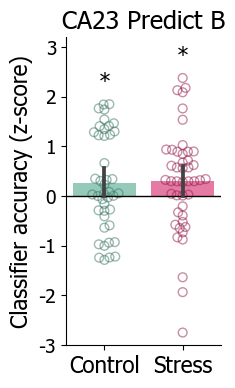

In [17]:
# convert each subject-level classifier score to a z-score based on SUBJECT-LEVEL distribution
np.random.seed(0)
iterations = 999

z_classifier_df = classifier_df.copy()

percentiles = []
means = []
medians = []
stds = []
for sub in z_classifier_df["subID"]:
    score = float(z_classifier_df.loc[z_classifier_df["subID"] == sub]["score"])
    if params is None:
        nulldist = np.load(f"./midpoints/classifier_nulldist/sub{sub}_{roi}_{classifier_type.replace('_', '')}_train{''.join([r[-1] for r in train_runs])}_test{''.join([r[-1] for r in test_runs])}_iterations{iterations}.npy")
    elif params == {'C': 1, 'k': 100}:
        nulldist = np.load(f"./midpoints/classifier_nulldist/sub{sub}_{roi}_{classifier_type.replace('_', '')}_train{''.join([r[-1] for r in train_runs])}_test{''.join([r[-1] for r in test_runs])}_iterations{iterations}_allvoxs.npy")
    
    percentiles.append(get_percentile_nulldist(score, nulldist))
    means.append(np.mean(nulldist))
    medians.append(np.median(nulldist))
    stds.append(np.std(nulldist))

z_classifier_df["null_mean"] = means
z_classifier_df["null_median"] = medians
z_classifier_df["null_std"] = stds
z_classifier_df["percentile"] = percentiles

# convert percentile to z-score
z_classifier_df["percentile_z"] = z_classifier_df["percentile"].apply(lambda x: scipy.stats.norm.ppf(x/100))

z_classifier_df["score_z"] = (z_classifier_df["score"] - z_classifier_df["null_mean"])/z_classifier_df["null_std"]
z_classifier_df.loc[(z_classifier_df["score"] == z_classifier_df["null_mean"]) & (z_classifier_df["null_std"] == 0)] = z_classifier_df.loc[(z_classifier_df["score"] == z_classifier_df["null_mean"]) & (z_classifier_df["null_std"] == 0)].fillna(0)

viz_y = "score_z"
viz_y_null = 0

fig, ax = plt.subplots(1, 1, figsize=(2, 4))
ax.axhline(0, color='k', linewidth=1)
sns.barplot(ax=ax, data=z_classifier_df, x="group", y=viz_y, palette=group_colors, saturation=1)
sns.swarmplot(ax=ax, data=z_classifier_df, x="group", y=viz_y, palette=dark_group_colors, alpha=0.5, s=4)
sns.despine()
plt.close()

fig2, ax2 = plt.subplots(1, 1, figsize=(2, 4))
ax2.axhline(viz_y_null, color='k', linewidth=1)
sns.barplot(ax=ax2, data=z_classifier_df, x="group", y=viz_y, palette=group_colors, saturation=1, order=groups)

for ci in range(len(ax.collections)):
    x_data, y_data = ax.collections[ci].get_offsets().T
    ax2.scatter(x_data, y_data, color="None", edgecolor=dark_group_colors[ci], s=40, alpha=0.5)

ax2.set_ylabel("Classifier accuracy (z-score)", fontsize=16)
ax2.set_yticklabels([f'{lab:.2f}'.rstrip('0').rstrip('.') for lab in ax2.get_yticks()], fontsize=14)
ax2.set_xticklabels(groups, fontsize=16)
ax2.set_xlabel("")
    
    
# perform statistical tests on classifier results and add significance stars
barxs = [line.get_data()[0][0] for line in ax2.get_lines()[1:]]
scatterys = [np.max(z_classifier_df[z_classifier_df["group"] == group][viz_y]) for group in groups]

yshift = np.diff(ax2.get_ylim())*0.05
max_stary = 0

# within-groups vs null
for i, group in zip(np.arange(len(groups)), groups):
    CI, pval = simple_bootstrap(np.array(z_classifier_df[z_classifier_df["group"] == group][viz_y]), iterations=99999, null=viz_y_null)
    rbc = wilcoxon_effsize(np.array(z_classifier_df[z_classifier_df["group"] == group][viz_y]), alternative="above")
    print(f'{groups[i]}: 95% CI {[np.round(i, 4) for i in CI]}, p={np.round(pval, 4)}, r={np.round(rbc, 4)}')
    
    star = pval2star(pval)
    
    if star != '':
        starx = barxs[i]
        stary = scatterys[i] + yshift
        if stary <= max_stary:
            stary = max_stary + yshift*3
        
        if stary > max_stary:
            max_stary = stary
            
        ax2.text(x=starx, y=stary, s=star, horizontalalignment="center", fontsize=16)

ax2.set_ylim([ax2.get_ylim()[0], ax2.get_ylim()[1]+2*yshift])
        
if "perception" in classifier_type:
    title = f"{roi} Represent {classifier_type[0]}"
elif classifier_type == "B_prediction":
    title = f"{roi} Predict B"
elif classifier_type == "A_lingering":
    title = f"{roi} Retrodict A"
    
ax2.set_title(title, fontsize=18)

sns.despine()
plt.show()